# Recurrent Neural Networks: Teaching a Machine to Remember
**Machine Learning & Neural Networks — Tutorial Assignment**

This notebook contains all code used in the tutorial, including intermediate steps not shown in the web page.

### References
- Rumelhart, D., Hinton, G., Williams, R. (1986). Learning representations by back-propagating errors. *Nature*, 323, 533–536. https://doi.org/10.1038/323533a0
- Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning.
- [Keras SimpleRNN documentation](https://keras.io/api/layers/recurrent_layers/simple_rnn/)
- [Understanding RNNs — Colah's Blog](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)
- [Jena Climate Dataset — TensorFlow tutorials](https://www.tensorflow.org/tutorials/structured_data/time_series)

## 1. Install & Import Libraries

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'tensorflow', 'numpy', 'pandas', 'matplotlib', 'scikit-learn', '-q'])
print('All libraries installed!')

All libraries installed!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

os.makedirs('figures', exist_ok=True)
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')
print('Ready!')

TensorFlow version: 2.19.0
Ready!


## 2. Load & Explore the Dataset

We use the **Jena Climate dataset** — hourly weather readings from a weather station in Jena, Germany (2009–2016). We will use daily mean temperature to keep things focused.

Our task: given the last N days of temperature, **predict the next day's temperature**.

In [4]:
df = pd.read_csv('/content/jena_climate_2009_2016.csv')

print(f'Raw dataset shape: {df.shape}')
print(df.head(3))

Raw dataset shape: (420551, 15)
             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.75      1.03           1.75     152.3  
1       1309.80      0.72           1.50     136.1  
2       1310.24      0.19           0.63     171.6  


In [5]:
# Use only temperature column, resample to daily mean
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df = df.set_index('Date Time')
temp_daily = df['T (degC)'].resample('D').mean().dropna()

print(f'Daily temperature records: {len(temp_daily)}')
print(f'Date range: {temp_daily.index[0].date()} to {temp_daily.index[-1].date()}')
print(f'Temperature range: {temp_daily.min():.1f}°C to {temp_daily.max():.1f}°C')

Daily temperature records: 2921
Date range: 2009-01-01 to 2017-01-01
Temperature range: -16.5°C to 29.4°C


## 3. Exploratory Data Analysis (skipped in tutorial)

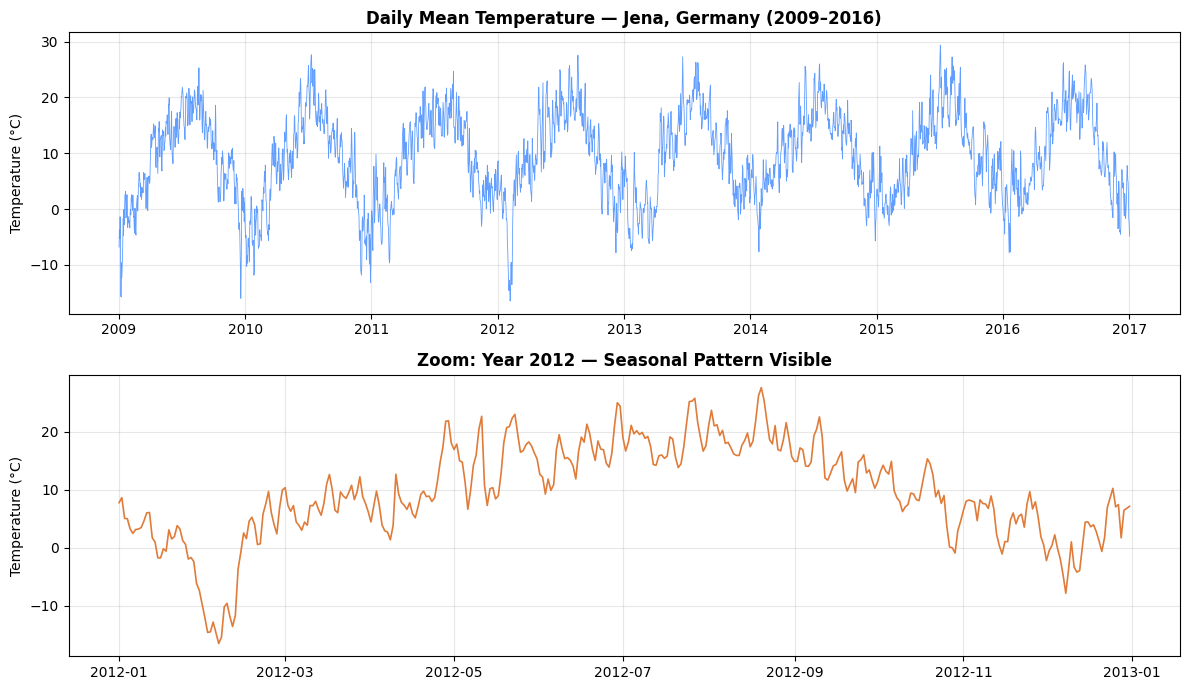

EDA figure saved.


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Full time series
axes[0].plot(temp_daily.index, temp_daily.values, color='#3a86ff', linewidth=0.6, alpha=0.8)
axes[0].set_title('Daily Mean Temperature — Jena, Germany (2009–2016)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Temperature (°C)')
axes[0].grid(True, alpha=0.3)

# One year zoom
year_data = temp_daily['2012']
axes[1].plot(year_data.index, year_data.values, color='#e07b39', linewidth=1.2)
axes[1].set_title('Zoom: Year 2012 — Seasonal Pattern Visible', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Temperature (°C)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/eda_temperature.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA figure saved.')

## 4. Figure 1 — The Problem: Why Standard MLPs Struggle with Sequences

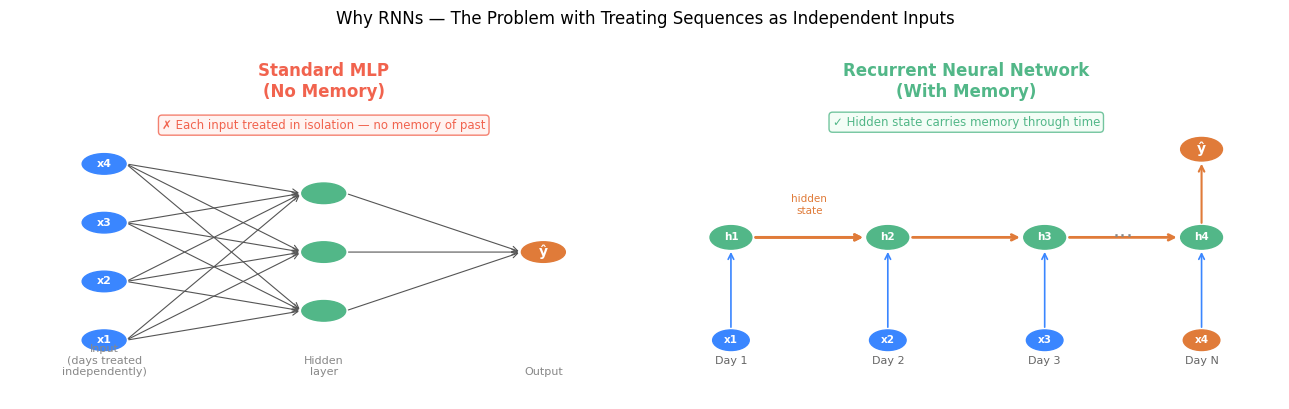

Figure 1 saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: MLP — treats each day independently
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title('Standard MLP\n(No Memory)', fontsize=12, fontweight='bold', color='#f1634e')

input_ys = [2, 4, 6, 8]
for i, y in enumerate(input_ys):
    circle = plt.Circle((1.5, y), 0.35, color='#3a86ff', zorder=3)
    ax.add_patch(circle)
    ax.text(1.5, y, f'x{i+1}', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

hidden_ys = [3, 5, 7]
for y in hidden_ys:
    circle = plt.Circle((5, y), 0.35, color='#52b788', zorder=3)
    ax.add_patch(circle)

out_circle = plt.Circle((8.5, 5), 0.35, color='#e07b39', zorder=3)
ax.add_patch(out_circle)
ax.text(8.5, 5, 'ŷ', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

for iy in input_ys:
    for hy in hidden_ys:
        ax.annotate('', xy=(4.65, hy), xytext=(1.85, iy),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=0.8))
for hy in hidden_ys:
    ax.annotate('', xy=(8.15, 5), xytext=(5.35, hy),
                arrowprops=dict(arrowstyle='->', color='#555', lw=0.8))

ax.text(1.5, 0.8, 'Input\n(days treated\nindependently)', ha='center', fontsize=8, color='#888')
ax.text(5, 0.8, 'Hidden\nlayer', ha='center', fontsize=8, color='#888')
ax.text(8.5, 0.8, 'Output', ha='center', fontsize=8, color='#888')
ax.text(5, 9.2, '✗ Each input treated in isolation — no memory of past', ha='center', fontsize=8.5, color='#f1634e',
        bbox=dict(boxstyle='round,pad=0.3', fc='#fff0ee', ec='#f1634e', alpha=0.8))

# Right: RNN — hidden state passed forward
ax2 = axes[1]
ax2.set_xlim(0, 12); ax2.set_ylim(0, 10); ax2.axis('off')
ax2.set_title('Recurrent Neural Network\n(With Memory)', fontsize=12, fontweight='bold', color='#52b788')

steps = [1.5, 4.5, 7.5, 10.5]
labels = ['Day 1', 'Day 2', 'Day 3', 'Day N']
colors_rnn = ['#3a86ff', '#3a86ff', '#3a86ff', '#e07b39']

for i, (x, lbl, col) in enumerate(zip(steps, labels, colors_rnn)):
    # input
    c_in = plt.Circle((x, 2), 0.35, color=col, zorder=3)
    ax2.add_patch(c_in)
    ax2.text(x, 2, f'x{i+1}', ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    # hidden
    c_h = plt.Circle((x, 5.5), 0.4, color='#52b788', zorder=3)
    ax2.add_patch(c_h)
    ax2.text(x, 5.5, f'h{i+1}', ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    # arrow up
    ax2.annotate('', xy=(x, 5.1), xytext=(x, 2.35),
                arrowprops=dict(arrowstyle='->', color='#3a86ff', lw=1.2))
    ax2.text(x, 1.2, lbl, ha='center', fontsize=8, color='#666')

# recurrent arrows
for i in range(len(steps)-1):
    ax2.annotate('', xy=(steps[i+1]-0.42, 5.5), xytext=(steps[i]+0.42, 5.5),
                arrowprops=dict(arrowstyle='->', color='#e07b39', lw=2))

# dots between step 3 and N
ax2.text(9, 5.5, '···', ha='center', va='center', fontsize=16, color='#888')

# output from last
c_out = plt.Circle((10.5, 8.5), 0.4, color='#e07b39', zorder=3)
ax2.add_patch(c_out)
ax2.text(10.5, 8.5, 'ŷ', ha='center', va='center', fontsize=10, color='white', fontweight='bold')
ax2.annotate('', xy=(10.5, 8.1), xytext=(10.5, 5.9),
            arrowprops=dict(arrowstyle='->', color='#e07b39', lw=1.5))

ax2.text(6, 9.3, '✓ Hidden state carries memory through time', ha='center', fontsize=8.5, color='#52b788',
        bbox=dict(boxstyle='round,pad=0.3', fc='#f0fdf4', ec='#52b788', alpha=0.8))
ax2.annotate('', xy=(4.08, 5.5), xytext=(1.92, 5.5),
            arrowprops=dict(arrowstyle='->', color='#e07b39', lw=2))
ax2.text(3, 6.3, 'hidden\nstate', ha='center', fontsize=7.5, color='#e07b39')

plt.suptitle('Why RNNs — The Problem with Treating Sequences as Independent Inputs', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('figures/mlp_vs_rnn_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## 5. Data Preprocessing — Create Sequences

In [8]:
# Normalise to [0, 1] — important for RNN training stability
values = temp_daily.values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values).flatten()

# Create sliding window sequences
# Given WINDOW days, predict next day
WINDOW = 30  # use last 30 days to predict next day

def make_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = make_sequences(scaled, WINDOW)
print(f'Total sequences: {len(X)}')
print(f'X shape: {X.shape}  →  (samples, timesteps)')
print(f'y shape: {y.shape}  →  (samples,)')

# Train/val/test split — chronological (never shuffle time series!)
n = len(X)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end],      y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],          y[val_end:]

# Reshape for Keras RNN: (samples, timesteps, features)
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print(f'\nTrain: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Total sequences: 2891
X shape: (2891, 30)  →  (samples, timesteps)
y shape: (2891,)  →  (samples,)

Train: (2023, 30, 1), Val: (434, 30, 1), Test: (434, 30, 1)


## 6. Figure 2 — The Sliding Window Concept

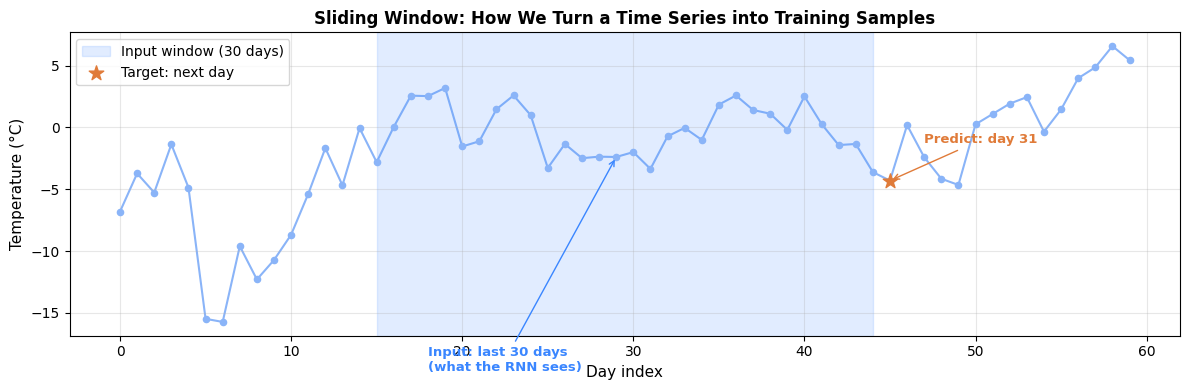

Figure 2 saved.


In [9]:
sample_data = temp_daily.values[:60]
sample_dates = temp_daily.index[:60]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(60), sample_data, color='#8ab4f8', linewidth=1.5, zorder=1)
ax.scatter(range(60), sample_data, color='#8ab4f8', s=20, zorder=2)

# Highlight window
win_start, win_end = 15, 44
ax.axvspan(win_start, win_end, alpha=0.15, color='#3a86ff', label=f'Input window (30 days)')
ax.scatter([win_end+1], [sample_data[win_end+1]], color='#e07b39', s=120,
           zorder=5, label='Target: next day', marker='*')

ax.annotate('Input: last 30 days\n(what the RNN sees)', xy=(29, sample_data[29]),
           xytext=(18, sample_data.min()-4), fontsize=9.5,
           arrowprops=dict(arrowstyle='->', color='#3a86ff'),
           color='#3a86ff', fontweight='bold')
ax.annotate('Predict: day 31', xy=(win_end+1, sample_data[win_end+1]),
           xytext=(win_end+3, sample_data[win_end+1]+3), fontsize=9.5,
           arrowprops=dict(arrowstyle='->', color='#e07b39'),
           color='#e07b39', fontweight='bold')

ax.set_xlabel('Day index', fontsize=11)
ax.set_ylabel('Temperature (°C)', fontsize=11)
ax.set_title('Sliding Window: How We Turn a Time Series into Training Samples', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/sliding_window.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## 7. Build & Train the RNN Model

In [10]:
def build_rnn(units=64, layers_n=1):
    model = keras.Sequential(name='SimpleRNN')
    model.add(keras.Input(shape=(WINDOW, 1)))
    for i in range(layers_n):
        return_seq = (i < layers_n - 1)  # only last layer returns single output
        model.add(layers.SimpleRNN(units, return_sequences=return_seq, activation='tanh'))
    model.add(layers.Dense(1))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

rnn_model = build_rnn(units=64, layers_n=1)
rnn_model.summary()

Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
print(f'\nTraining stopped at epoch {len(history.history["loss"])}')

Epoch 1/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0155 - mae: 0.0874 - val_loss: 0.0043 - val_mae: 0.0519
Epoch 2/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0045 - mae: 0.0536 - val_loss: 0.0035 - val_mae: 0.0464
Epoch 3/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0040 - mae: 0.0503 - val_loss: 0.0032 - val_mae: 0.0444
Epoch 4/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0037 - mae: 0.0482 - val_loss: 0.0030 - val_mae: 0.0430
Epoch 5/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0035 - mae: 0.0465 - val_loss: 0.0029 - val_mae: 0.0423
Epoch 6/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0033 - mae: 0.0453 - val_loss: 0.0028 - val_mae: 0.0419
Epoch 7/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0032 - mae: 0.0444 - val_loss: 0.0028 - val_mae: 0.0417
Epoch 8/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0031 - mae: 0.0437 - val_loss: 0.0028 - val_mae: 0.0417
Epoch 9/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0030 - m

## 8. Figure 3 — Training History

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history.history['loss'], label='Train Loss (MSE)', color='#e07b39', linewidth=2)
ax.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='#3a86ff', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss (MSE)', fontsize=11)
ax.set_title('RNN Training History — Loss Curves', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## 9. Figure 4 — Predictions vs Actual

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Test MAE:  1.83°C
Test RMSE: 2.31°C


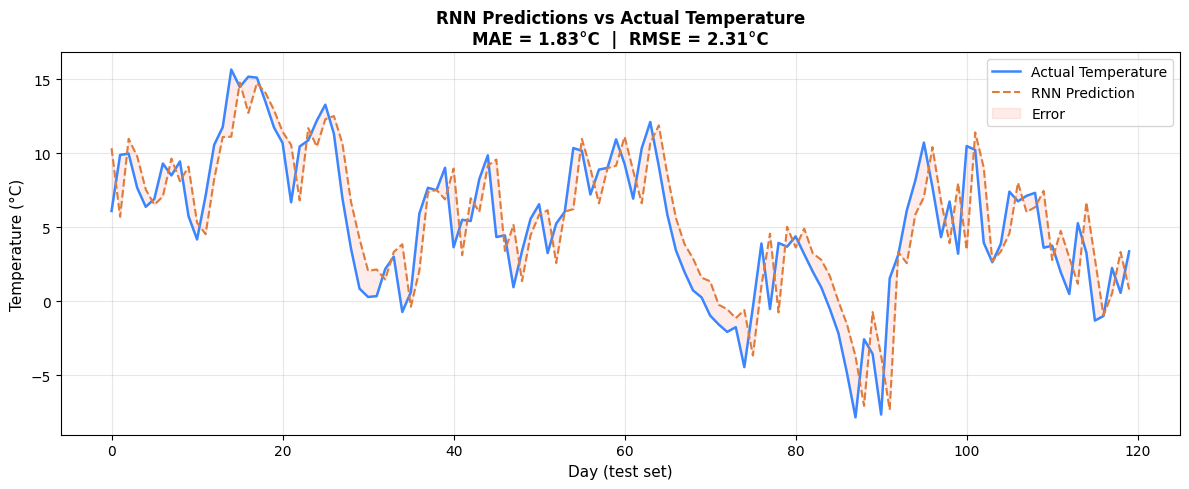

Figure 4 saved.


In [12]:
# Predictions on test set
y_pred_scaled = rnn_model.predict(X_test).flatten()

# Inverse transform to real temperatures
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Metrics
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f'Test MAE:  {mae:.2f}°C')
print(f'Test RMSE: {rmse:.2f}°C')

# Plot first 120 test days
n_plot = 120
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(n_plot), y_true[:n_plot], label='Actual Temperature', color='#3a86ff', linewidth=1.8)
ax.plot(range(n_plot), y_pred[:n_plot], label='RNN Prediction', color='#e07b39',
        linewidth=1.5, linestyle='--')
ax.fill_between(range(n_plot), y_true[:n_plot], y_pred[:n_plot],
                alpha=0.12, color='#f1634e', label='Error')
ax.set_xlabel('Day (test set)', fontsize=11)
ax.set_ylabel('Temperature (°C)', fontsize=11)
ax.set_title(f'RNN Predictions vs Actual Temperature\nMAE = {mae:.2f}°C  |  RMSE = {rmse:.2f}°C',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## 10. Experiment — How Does Window Size Affect Performance?

In [13]:
window_sizes = [7, 14, 21, 30, 45, 60]
results = []

for w in window_sizes:
    Xw, yw = make_sequences(scaled, w)
    n = len(Xw)
    te = int(n * 0.7); ve = int(n * 0.85)
    Xtr = Xw[:te][..., np.newaxis];  ytr = yw[:te]
    Xv  = Xw[te:ve][..., np.newaxis]; yv  = yw[te:ve]
    Xte = Xw[ve:][..., np.newaxis];   yte = yw[ve:]

    m = keras.Sequential([
        keras.Input(shape=(w, 1)),
        layers.SimpleRNN(64, activation='tanh'),
        layers.Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    m.fit(Xtr, ytr, validation_data=(Xv, yv), epochs=50, batch_size=32,
          callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)],
          verbose=0)

    pred = scaler.inverse_transform(m.predict(Xte, verbose=0)).flatten()
    true = scaler.inverse_transform(yte.reshape(-1,1)).flatten()
    mae_w = mean_absolute_error(true, pred)
    results.append({'window': w, 'mae': mae_w})
    print(f'Window={w:3d} days → MAE={mae_w:.3f}°C')

results_df = pd.DataFrame(results)
print('\n', results_df)

Window=  7 days → MAE=1.802°C
Window= 14 days → MAE=1.895°C
Window= 21 days → MAE=1.826°C
Window= 30 days → MAE=1.824°C
Window= 45 days → MAE=1.825°C
Window= 60 days → MAE=1.835°C

    window       mae
0       7  1.802285
1      14  1.894535
2      21  1.825560
3      30  1.824218
4      45  1.824937
5      60  1.835210


## 11. Figure 5 — Window Size vs MAE

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(results_df['window'], results_df['mae'], 'o-', color='#3a86ff', linewidth=2.5, markersize=8)
best_idx = results_df['mae'].idxmin()
best_w = results_df.loc[best_idx, 'window']
best_mae = results_df.loc[best_idx, 'mae']
ax.scatter([best_w], [best_mae], color='#e07b39', s=180, zorder=5,
           label=f'Best: window={best_w}, MAE={best_mae:.2f}°C')
ax.set_xlabel('Window Size (days)', fontsize=11)
ax.set_ylabel('Test MAE (°C)', fontsize=11)
ax.set_title('How Much Past Data Should the RNN See?\nWindow Size vs Prediction Error', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/window_vs_mae.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')